<a href="https://colab.research.google.com/github/MathiasGarnier/Algorithms-All---Old/blob/master/notebooks/HNS_seance_intro_%231.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Humanités numériques spatialisées — séance 1 : les données spatiales

In [2]:
# décommenter si un module manque :
!pip install -q geopandas mapclassify esda libpysal rasterio geopy

import json, os
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from shapely import wkt
from shapely.geometry import Point, LineString, Polygon, MultiPolygon, box
from pyproj import CRS, Transformer, Geod

os.makedirs("data_demo", exist_ok=True)
geod = Geod(ellps="WGS84")            # calculs de distances / surfaces sur l'ellipsoïde

LIEUE_POSTE_M = 3898                  # lieue de poste (France) ≈ 3,9 km ; les lieues varient selon l'époque et la région
LEGUA_M = 5572.7                      # legua castellana ≈ 5,57 km

def aire_reelle_km2(geom_4326):
    # aire d'une géométrie en lon/lat (EPSG:4326), calculée sur l'ellipsoïde
    return abs(geod.geometry_area_perimeter(geom_4326)[0]) / 1e6

## 1. Données spatiales
> Toute observation dont on connaît non seulement la **valeur**, mais aussi la **localisation**.

      nom     lon      lat  nb_mentions_corpus                 geometry
0  Nantes -1.5536  47.2184                  42  POINT (-1.5536 47.2184)
1   Paris  2.3522  48.8566                 130   POINT (2.3522 48.8566)
2  Rennes -1.6778  48.1173                  18  POINT (-1.6778 48.1173)
3  Angers -0.5518  47.4784                  25  POINT (-0.5518 47.4784)


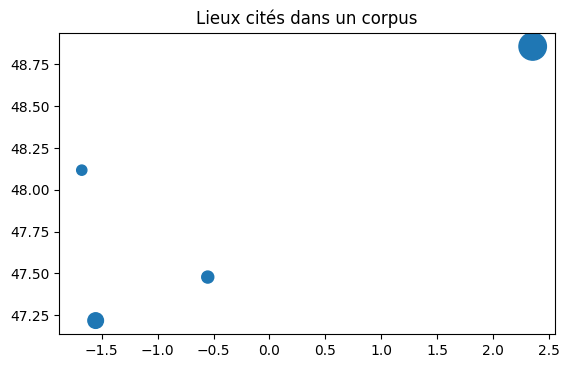

In [ ]:
lieux = pd.DataFrame({
    "nom":  ["Nantes", "Paris", "Rennes", "Angers"],
    "lon":  [-1.5536, 2.3522, -1.6778, -0.5518],
    "lat":  [47.2184, 48.8566, 48.1173, 47.4784],
    "nb_mentions_corpus": [42, 130, 18, 25],          # la « valeur »
})
gdf = gpd.GeoDataFrame(
    lieux,
    geometry=gpd.points_from_xy(lieux["lon"], lieux["lat"]),   # (x, y) = (lon, lat)
    crs="EPSG:4326",
)
print(gdf)
gdf.plot(markersize=gdf["nb_mentions_corpus"] * 3)
plt.title("Lieux cités dans un corpus"); plt.show()

### 🧪 Exercice — Du tableau à la couche spatiale
Le tableau `villes` contient des latitudes et longitudes (valeurs approximatives, à titre illustratif).
Transformez-le en `GeoDataFrame` en **WGS 84**, puis affichez-le.
*Vérification : les 4 points doivent tomber en France métropolitaine (longitudes entre -5 et 10, latitudes entre 41 et 52).*

In [ ]:
villes = pd.DataFrame({
    "ville": ["Lyon", "Marseille", "Lille", "Bordeaux"],
    "latitude": [45.7640, 43.2965, 50.6292, 44.8378],
    "longitude": [4.8357, 5.3698, 3.0573, -0.5792],
    "habitants_milliers": [520, 870, 235, 260],
})

# votre code ici

## 2. Référencement spatial indirect et direct

- **Indirect** : la localisation n'est pas donnée en coordonnées mais par un toponyme, une adresse, une relation dans un texte (dictionnaire géographique, liste de rues, tableau d'assemblage…). Il faut la **convertir** en coordonnées (géocodage).
- **Direct** : les coordonnées sont fournies (base de données, données du Web…).

In [ ]:
import requests
try:
    r = requests.get("https://api-adresse.data.gouv.fr/search/",
                     params={"q": "65 rue de Richelieu Paris", "limit": 1}, timeout=15)
    f = r.json()["features"][0]
    print(f["properties"]["label"], "→ (lon, lat) =", f["geometry"]["coordinates"])   # GeoJSON = [lon, lat]
except Exception as e:
    print("Pas d'accès réseau :", e)

65 Rue de Richelieu 75002 Paris → (lon, lat) = [2.337596, 48.867298]


In [ ]:
# Alternative généraliste (toponymes du monde entier, OSM/Nominatim) :
from geopy.geocoders import Nominatim
loc = Nominatim(user_agent="cours_hns").geocode("65 rue de Richelieu Paris, France"); print(loc.latitude, loc.longitude)

48.8672987 2.3376102


In [ ]:
# Une relation spatiale écrite en langue naturelle : « … está 15 leguas al Oriente de su Capital » (dictionnaire d'Alcedo)
# → un point de départ + une direction (azimut) + une distance
capitale = (-96.15, 17.33)          # (lon, lat) APPROXIMATIFS et illustratifs ; que désigne exactement « su Capital » ?
azimut_est = 90                     # 0 = nord, 90 = est, 180 = sud, 270 = ouest

lon2, lat2, _ = geod.fwd(*capitale, azimut_est, 15 * LEGUA_M)
print(f"15 leguas à l'est → (lon, lat) = ({lon2:.3f}, {lat2:.3f}) — soit {15 * LEGUA_M / 1000:.0f} km")

15 leguas à l'est → (lon, lat) = (-95.364, 17.328) — soit 84 km


**geod.fwd** : méthode de la bibliothèque Python pyproj qui permet de calculer la position d'un point d'arrivée (latitude, longitude) et l'azimut retour en partant d'un point initial, d'un azimut (direction) et d'une distance donnée.

## 3. Coordonnées
Degrés décimaux ↔ degrés-minutes-secondes, et le piège de l'ordre des axes.

In [ ]:
def dd_to_dms(dd, axis="lat"):
    hemi = ("N" if dd >= 0 else "S") if axis == "lat" else ("E" if dd >= 0 else "W")
    a = abs(dd); d = int(a); m = int((a - d) * 60); s = (a - d - m / 60) * 3600
    return f"{d}°{m:02d}′{s:05.2f}″ {hemi}"

def dms_to_dd(d, m, s, hemi):
    v = d + m / 60 + s / 3600
    return -v if hemi in ("S", "W") else v

lat, lon = 48.85296, 2.34992    # Notre-Dame de Paris
print(dd_to_dms(lat, "lat"), "|", dd_to_dms(lon, "lon"))
print(dms_to_dd(48, 51, 10.66, "N"))

48°51′10.66″ N | 2°20′59.71″ E
48.852961111111114


In [ ]:
# PIÈGE : « lat, lon » (usage courant, GPS, Google Maps) vs (x, y) = (lon, lat) (GeoJSON, WKT, Shapely)
p_correct = Point(lon, lat)      # x = longitude, y = latitude
p_inverse = Point(lat, lon)      # erreur classique : on tombe dans l'océan Indien
print(p_correct, "|", p_inverse)

# Et dans pyproj : EPSG:4326 déclare l'ordre (lat, lon) !
print([a.abbrev for a in CRS.from_epsg(4326).axis_info])   # ['Lat', 'Lon']

POINT (2.34992 48.85296) | POINT (48.85296 2.34992)
['Lat', 'Lon']


### 🧪 Exercice — Chasser l'inversion lat/lon
Ce fichier fictif liste des villes avec `(nom, latitude, longitude)`. Construisez les objets `Point` **corrects**, puis vérifiez qu'ils sont tous dans la boîte englobante de la France (`-5.5 < x < 10` et `41 < y < 51.5`).
Que se passerait-il en écrivant `Point(lat, lon)` ?

In [ ]:
liste = [("Nantes", 47.2184, -1.5536), ("Rennes", 48.1173, -1.6778), ("Lille", 50.6292, 3.0573)]
def dans_france(p):
    return -5.5 < p.x < 10 and 41 < p.y < 51.5

# votre code ici

## 4. Systèmes de coordonnées et de projection
Même lieu, deux systèmes ; puis les conséquences sur les distances.

In [ ]:
to_l93 = Transformer.from_crs("EPSG:4326", "EPSG:2154", always_xy=True)
x, y = to_l93.transform(lon, lat)
print(f"WGS84 : ({lon}, {lat})  →  Lambert 93 : ({x:.0f} m, {y:.0f} m)")

# Avec GeoPandas : reprojection d'une couche entière
print(gdf.to_crs(2154).geometry.head(2))

WGS84 : (2.34992, 48.85296)  →  Lambert 93 : (652298 m, 6861632 m)
0    POINT (355577.802 6689723.103)
1    POINT (652469.023 6862035.259)
Name: geometry, dtype: geometry


In [ ]:
# Distance Paris–Nantes : trois méthodes, trois résultats
paris, nantes = (2.3522, 48.8566), (-1.5536, 47.2184)

d_geod = geod.inv(*paris, *nantes)[2] / 1000                      # « vraie » distance sur l'ellipsoïde

pl, nl = to_l93.transform(*paris), to_l93.transform(*nantes)    # Lambert 93 (France), un système projeté (mètres)
d_l93  = np.hypot(pl[0]-nl[0], pl[1]-nl[1]) / 1000              # Pythagore en Lambert 93 (mètres)

print(f"Ellipsoïde : {d_geod:.1f} km | Lambert 93 : {d_l93:.1f} km")

Ellipsoïde : 343.5 km | Lambert 93 : 343.3 km


En QGIS, Préférences > Options > Mesures, sélectionnez l'ellipsoïde adapté (par exemple, WGS 84) pour que les distances soient calculées sur la surface de la terre de référence et non sur le plan de la projection.

## 5. Familles de projections
La même grille de méridiens/parallèles dans trois familles : azimutale, conique, cylindrique.

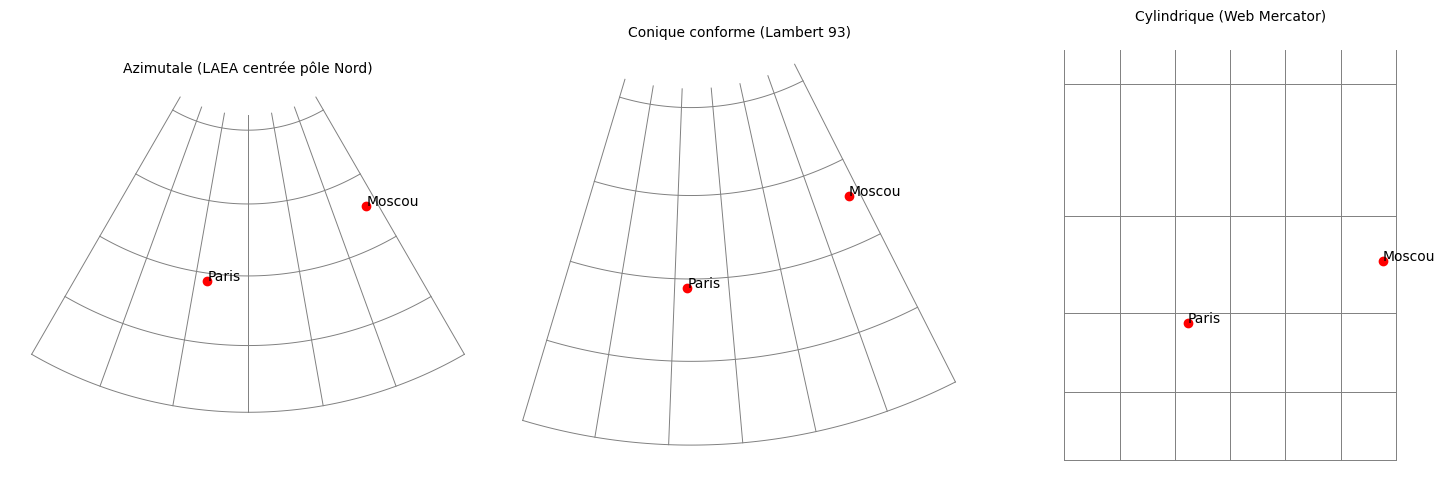

In [ ]:
projs = {
    "Azimutale (LAEA centrée pôle Nord)": "+proj=laea +lat_0=90 +lon_0=10 +datum=WGS84",
    "Conique conforme (Lambert 93)":      "EPSG:2154",
    "Cylindrique (Web Mercator)":         "EPSG:3857",
}
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (nom, crs) in zip(axes, projs.items()):
    tr = Transformer.from_crs(4326, crs, always_xy=True)

    for lo in range(-20, 41, 10):                       # dessiner les méridiens
        la = np.linspace(30, 72, 60); xs, ys = tr.transform(np.full_like(la, lo), la)
        ax.plot(xs, ys, color="gray", lw=.7)

    for la0 in range(30, 71, 10):                       # dessiner les parallèles
        lo = np.linspace(-20, 40, 100); xs, ys = tr.transform(lo, np.full_like(lo, la0))
        ax.plot(xs, ys, color="gray", lw=.7)

    for ville, (lo, la) in {"Paris": (2.35, 48.85), "Moscou": (37.6, 55.75)}.items():
        px, py = tr.transform(lo, la); ax.plot(px, py, "ro"); ax.annotate(ville, (px, py))

    ax.set_title(nom, fontsize=10); ax.set_aspect("equal"); ax.axis("off")
plt.tight_layout(); plt.show()

In [ ]:
familles = {"Lambert 93 (EPSG:2154)": "conique", "Web Mercator (EPSG:3857)": "cylindrique", "LAEA (Lambert azimutale équivalente)": "azimutale"}
proprietes = {"Lambert 93 (EPSG:2154)": "conforme", "Web Mercator (EPSG:3857)": "conforme", "LAEA (Lambert azimutale équivalente)": "équivalente"}
print(pd.DataFrame({"famille": familles, "propriété": proprietes}))

                                          famille    propriété
Lambert 93 (EPSG:2154)                    conique     conforme
Web Mercator (EPSG:3857)              cylindrique     conforme
LAEA (Lambert azimutale équivalente)    azimutale  équivalente


In [ ]:
from pyproj import CRS
for c in (2154, 3857, 3035, 4087):
    crs = CRS.from_epsg(c)
    print(c, "|", crs.name, "|", crs.coordinate_operation.method_name)

2154 | RGF93 v1 / Lambert-93 | Lambert Conic Conformal (2SP)
3857 | WGS 84 / Pseudo-Mercator | Popular Visualisation Pseudo Mercator
3035 | ETRS89-extended / LAEA Europe | Lambert Azimuthal Equal Area
4087 | WGS 84 / World Equidistant Cylindrical | Equidistant Cylindrical



Quelle propriété choisiriez-vous pour une carte comparant des **surfaces** ?

## 6. Système d'information géographique : couches et formats

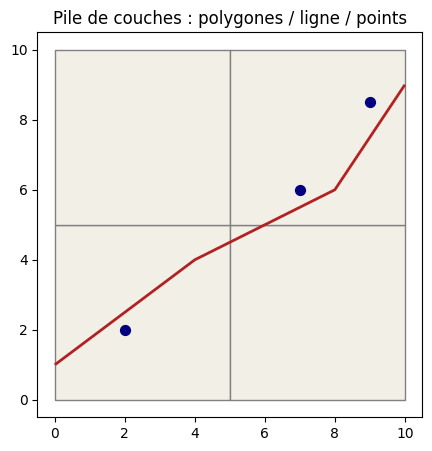

In [ ]:
# Trois couches de thèmes différents, superposées

communes = gpd.GeoDataFrame({"nom": list("ABCD") },
    geometry=[box(0,0,5,5), box(5,0,10,5), box(0,5,5,10), box(5,5,10,10)], crs="EPSG:2154")

route  = gpd.GeoDataFrame({"type": ["voie"]}, geometry=[LineString([(0,1),(4,4),(8,6),(10,9)])], crs="EPSG:2154")

sites  = gpd.GeoDataFrame({"site": ["s1", "s2", "s3"]},
    geometry=[Point(2,2), Point(7,6), Point(9,8.5)], crs="EPSG:2154")

fig, ax = plt.subplots(figsize=(5, 5))

communes.plot(ax=ax, color="#f2efe6", edgecolor="gray")

route.plot(ax=ax, color="firebrick", lw=2)

sites.plot(ax=ax, color="navy", markersize=50)

ax.set_title("Pile de couches : polygones / ligne / points"); plt.show()

In [ ]:
# Écrire dans différents formats — et voir les limites du Shapefile
communes.to_file("data_demo/demo.gpkg", layer="communes", driver="GPKG")   # recommandé : 1 fichier, multi-couches
route.to_file("data_demo/demo.gpkg",    layer="route",    driver="GPKG")
communes.to_file("data_demo/communes.geojson", driver="GeoJSON")           # web, WGS84 attendu par la norme
communes.to_file("data_demo/communes.shp")                                  # ⚠ champs tronqués à 10 caractères

print(gpd.list_layers("data_demo/demo.gpkg"))
print("Colonnes Shapefile :", list(gpd.read_file("data_demo/communes.shp").columns))
print("Fichiers .shp :", sorted(f for f in os.listdir("data_demo") if f.startswith("communes.") and not f.endswith("geojson")))

# CSV avec lat/lon → couche de points
df = pd.DataFrame({"nom": ["A", "B"], "lon": [-1.55, 2.35], "lat": [47.22, 48.85]})
pts = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat), crs=4326)

       name geometry_type
0  communes       Polygon
1     route    LineString
Colonnes Shapefile : ['nom', 'geometry']
Fichiers .shp : ['communes.cpg', 'communes.dbf', 'communes.prj', 'communes.shp', 'communes.shx']


## 7. Données vecteur : primitives géométriques, WKT, GeoJSON, attributs

In [ ]:
pt   = Point(-1.5536, 47.2184)
ligne = LineString([(0, 0), (2, 1), (4, 0.5)])
poly  = Polygon([(0, 0), (4, 0), (4, 3), (0, 3)])        # se ferme tout seul : 1er point = dernier point

for g in (pt, ligne, poly):
    print(g.geom_type.ljust(10), "|", g.wkt)

print("Coordonnées du polygone :", list(poly.exterior.coords))    # noter la répétition du 1er point

print("aire =", poly.area, "| longueur de la ligne =", round(ligne.length, 2))

Point      | POINT (-1.5536 47.2184)
LineString | LINESTRING (0 0, 2 1, 4 0.5)
Polygon    | POLYGON ((0 0, 4 0, 4 3, 0 3, 0 0))
Coordonnées du polygone : [(0.0, 0.0), (4.0, 0.0), (4.0, 3.0), (0.0, 3.0), (0.0, 0.0)]
aire = 12.0 | longueur de la ligne = 4.3


In [ ]:
# Le même polygone en WKT et en GeoJSON
print(poly.wkt)
print(json.dumps(poly.__geo_interface__))

# Lecture inverse : WKT → géométrie (très utile pour Wikidata, QGIS, bases de données spatiales)
g = wkt.loads("POINT(-1.5536 47.2184)")
print(g.x, g.y)

POLYGON ((0 0, 4 0, 4 3, 0 3, 0 0))
{"type": "Polygon", "coordinates": [[[0.0, 0.0], [4.0, 0.0], [4.0, 3.0], [0.0, 3.0], [0.0, 0.0]]]}
-1.5536 47.2184


In [ ]:
# Polygone avec un trou, et multi-polygone (une commune avec une île)
avec_trou = Polygon(shell=[(0,0),(10,0),(10,10),(0,10)], holes=[[(4,4),(6,4),(6,6),(4,6)]])

ile = Polygon([(12,2),(14,2),(14,4),(12,4)])

commune = MultiPolygon([avec_trou, ile])

print("aire =", commune.area, "| nb de parties =", len(commune.geoms))

# Géométrie + attributs = une table
gdf_v = gpd.GeoDataFrame({"nom": ["Commune X"], "population": [1234]}, geometry=[commune], crs="EPSG:2154")
gdf_v

aire = 100.0 | nb de parties = 2


,nom,population,geometry
0,Commune X,1234,"MULTIPOLYGON (((0 0, 10 0, 10 10, 0 10, 0 0), ..."


## 8. Données raster : matrice de cellules, résolution
Un raster est positionné dans l'espace par un **coin d'origine** et une **taille de pixel** ; chaque cellule porte une valeur.

In [ ]:
import rasterio
from rasterio.transform import from_origin
from rasterio.io import MemoryFile

# MNT synthétique : deux collines, pixels de 25 m, 240×240
n = 240
xx, yy = np.meshgrid(np.linspace(-3, 3, n), np.linspace(-3, 3, n))
mnt = (120*np.exp(-((xx+1)**2 + (yy+.5)**2)) + 80*np.exp(-((xx-1.5)**2 + (yy-1)**2)/.5)).astype("float32")

transform = from_origin(west=355000, north=6695000, xsize=25, ysize=25)   # coin haut-gauche + taille de pixel
profile = dict(driver="GTiff", height=n, width=n, count=1, dtype="float32", crs="EPSG:2154", transform=transform)
with MemoryFile() as mem:
    with mem.open(**profile) as dst:
        dst.write(mnt, 1)
    with mem.open() as src:
        print("Taille :", src.shape, "| résolution :", src.res, "| CRS :", src.crs)
        print("Emprise :", src.bounds)
        a = src.read(1)
        print("alt. min/max :", a.min().round(1), a.max().round(1))
        print("Valeur au point (x, y) = (358000, 6692000) :", a[src.index(358000, 6692000)])   # coord. → (ligne, col)

Taille : (240, 240) | résolution : (25.0, 25.0) | CRS : EPSG:2154
Emprise : BoundingBox(left=355000.0, bottom=6689000.0, right=361000.0, top=6695000.0)
alt. min/max : 0.0 120.0
Valeur au point (x, y) = (358000, 6692000) : 33.235825


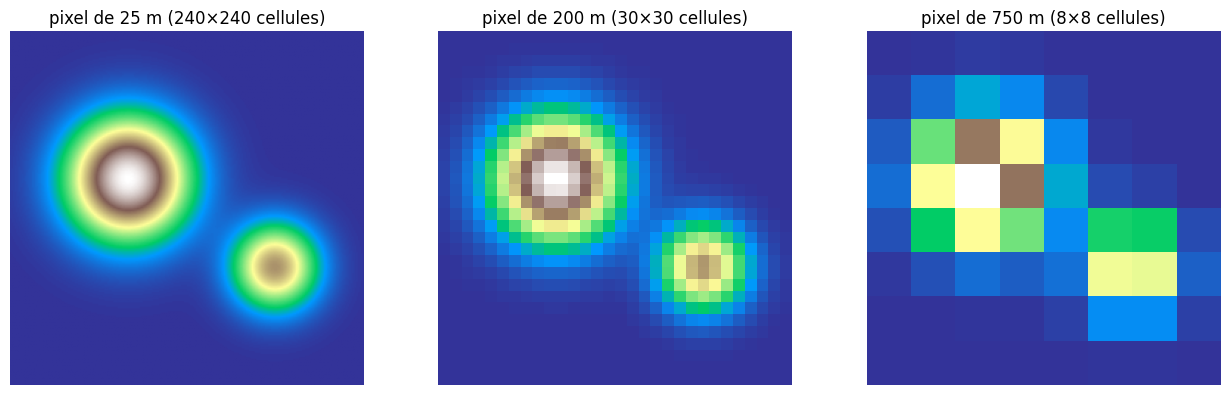

In [ ]:
# La taille des cellules détermine la finesse
def coarsen(a, k):
    h, w = a.shape
    return a.reshape(h//k, k, w//k, k).mean(axis=(1, 3))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, k in zip(axes, (1, 8, 30)):
    im = ax.imshow(coarsen(mnt, k), cmap="terrain")
    ax.set_title(f"pixel de {25*k} m ({mnt.shape[0]//k}×{mnt.shape[0]//k} cellules)"); ax.axis("off")
plt.tight_layout(); plt.show()

## 9. Raster ou vecteur
Rastériser (vecteur → raster) et vectoriser (raster → vecteur).

Aire vecteur : 45.0


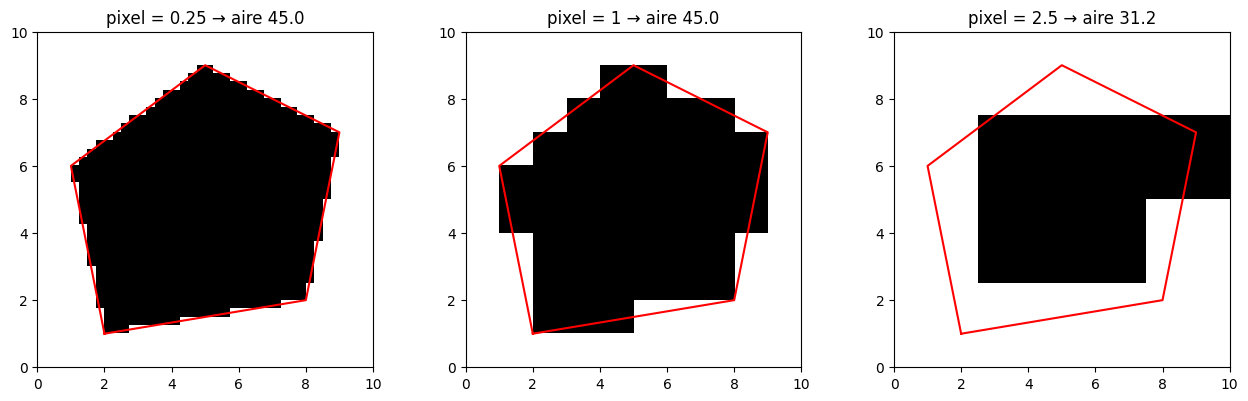

Polygone vectorisé : aire = 45.0 | nb de sommets = 69


In [ ]:
from rasterio.features import rasterize, shapes
from shapely.geometry import shape

forme = Polygon([(2,1),(8,2),(9,7),(5,9),(1,6)])          # une « parcelle » vecteur
print("Aire vecteur :", round(forme.area, 2))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, taille in zip(axes, (0.25, 1, 2.5)):
    n_px = int(10 / taille)
    tr = from_origin(0, 10, taille, taille)
    r = rasterize([(forme, 1)], out_shape=(n_px, n_px), transform=tr, fill=0, dtype="uint8")
    aire_raster = r.sum() * taille**2
    ax.imshow(r, extent=(0, 10, 0, 10), cmap="Greys")
    ax.plot(*forme.exterior.xy, color="red")
    ax.set_title(f"pixel = {taille} → aire {aire_raster:.1f}")
plt.tight_layout(); plt.show()

# Vectorisation : raster → polygones
r = rasterize([(forme, 1)], out_shape=(40, 40), transform=from_origin(0, 10, .25, .25), fill=0, dtype="uint8")
polys = [shape(g) for g, v in shapes(r, transform=from_origin(0, 10, .25, .25)) if v == 1]
print("Polygone vectorisé : aire =", polys[0].area, "| nb de sommets =", len(polys[0].exterior.coords))

### Le prix de la grille
Pour des tailles de pixel de 0,1 ; 0,25 ; 0,5 ; 1 ; 2 ; 2,5 et 5, on peut calculer l'**erreur relative** (en %) sur l'aire de `forme` après rastérisation.

À partir de quelle taille dépasse-t-elle 5 % ? Quel est l'avantage du raster malgré cela ?

In [ ]:
# Indice : boucle sur les tailles ; n_px = int(10 / taille) ; erreur = abs(aire_raster - forme.area) / forme.area * 100

for taille in (0.1, 0.25, 0.5, 1, 2, 2.5, 5):
    n_px = int(10 / taille)
    r = rasterize([(forme, 1)], out_shape=(n_px, n_px), transform=from_origin(0, 10, taille, taille), fill=0, dtype="uint8")
    err = abs(r.sum() * taille**2 - forme.area) / forme.area * 100
    print(f"pixel {taille:>4} → erreur {err:5.1f} %")

pixel  0.1 → erreur   0.0 %
pixel 0.25 → erreur   0.0 %
pixel  0.5 → erreur   0.0 %
pixel    1 → erreur   0.0 %
pixel    2 → erreur  11.1 %
pixel  2.5 → erreur  30.6 %
pixel    5 → erreur  66.7 %


## 10 Topologie : erreurs typiques
Chevauchements et trous entre parcelles ou communes, géométries invalides.

In [ ]:
import shapely
# Trois parcelles numérisées « à la main » : un trou (0,2 entre A et B) et un chevauchement (B/C)
A = box(0, 0, 10, 10)
B = box(10.2, 0, 20, 10)
C = box(19.5, 0, 30, 10)
parcelles = gpd.GeoDataFrame({"id": list("ABC")}, geometry=[A, B, C], crs="EPSG:2154")

for i in range(len(parcelles)):
    for j in range(i+1, len(parcelles)):
        inter = parcelles.geometry[i].intersection(parcelles.geometry[j])
        if inter.area > 0:
            print(f"Chevauchement {parcelles.id[i]}/{parcelles.id[j]} : aire = {inter.area}")

union = shapely.union_all(parcelles.geometry.values)
trous = union.envelope.difference(union)
print("Trous entre parcelles :", [round(t.area, 2) for t in getattr(trous, "geoms", [trous])])

Chevauchement B/C : aire = 5.0
Trous entre parcelles : [2.0]


In [ ]:
# Validité d'une géométrie : le « nœud papillon »
noeud = Polygon([(0,0), (4,4), (4,0), (0,4)])
print("valide ?", noeud.is_valid, "|", shapely.is_valid_reason(noeud))
repare = shapely.make_valid(noeud)
print("après réparation :", repare.geom_type, "| aire =", repare.area)

# Snapping : recoller des sommets presque coïncidents
B_recolle = shapely.snap(B, A, tolerance=0.3)
u = shapely.union_all([A, B_recolle])
print("Aire du trou après snap :", round(u.envelope.difference(u).area, 3))

valide ? False | Self-intersection[2 2]
après réparation : MultiPolygon | aire = 8.0
Aire du trou après snap : 0.0


## 11. Relations spatiales : proximité, topologiques, cardinales
Elles sont implicites et **calculables**.

In [ ]:
# Topologiques : prédicats
parc = gpd.GeoDataFrame({"paroisse": ["P1", "P2"]}, geometry=[box(0,0,5,5), box(5,0,10,5)], crs=2154)
couvent = gpd.GeoDataFrame({"nom": ["Couvent des Cordeliers"]}, geometry=[Point(2, 2)], crs=2154)   # exemple fictif
voie = gpd.GeoDataFrame({"nom": ["voie"]}, geometry=[LineString([(0, 2.5), (10, 2.5)])], crs=2154)

p1, p2 = parc.geometry
print("P1 contient le couvent :", p1.contains(couvent.geometry[0]))
print("P1 touche P2           :", p1.touches(p2), "| P1 intersecte P2 :", p1.intersects(p2))
print("La voie croise P1      :", voie.geometry[0].crosses(p1))

# Jointure spatiale : quelle paroisse contient quel couvent ?
print(gpd.sjoin(couvent, parc, predicate="within")[["nom", "paroisse"]])

P1 contient le couvent : True
P1 touche P2           : True | P1 intersecte P2 : True
La voie croise P1      : True
                      nom paroisse
0  Couvent des Cordeliers       P1


In [ ]:
# Proximité : sites à moins de 5 km d'une voie (toujours en CRS projeté, en mètres !)
voie_m = gpd.GeoDataFrame(geometry=[LineString([(355000, 6690000), (365000, 6693000)])], crs=2154)
sites_m = gpd.GeoDataFrame({"site": ["villa", "temple", "nécropole"]},
    geometry=[Point(358000, 6691500), Point(360000, 6700000), Point(364000, 6693500)], crs=2154)

zone = voie_m.buffer(5000)
sites_m["proche_voie"] = sites_m.within(zone.iloc[0])
print(sites_m[["site", "proche_voie"]])

# Plus proche voisin + distance
print(gpd.sjoin_nearest(sites_m, voie_m, distance_col="dist_m")[["site", "dist_m"]].round(0))

        site  proche_voie
0      villa         True
1     temple        False
2  nécropole         True
        site  dist_m
0      villa   575.0
1     temple  8142.0
2  nécropole   766.0


In [ ]:
# Du texte à la zone : « à trois lieues de Paris »
paris = (2.3522, 48.8566)          # (lon, lat)
paris_m = gpd.GeoSeries([Point(paris)], crs=4326).to_crs(2154)
rayon = paris_m.buffer(3 * LIEUE_POSTE_M)

candidats = gpd.GeoDataFrame({"nom": ["Montreuil", "Saint-Denis", "Boulogne-Billancourt", "Versailles", "Saint-Germain-en-Laye", "Meaux", "Fontainebleau"]},
    geometry=gpd.points_from_xy([2.4485, 2.3574, 2.2410, 2.1301, 2.0940, 2.8788, 2.7016],
                                [48.8638, 48.9362, 48.8352, 48.8014, 48.8985, 48.9606, 48.4047]), crs=4326).to_crs(2154)
candidats["dist_km"] = (candidats.distance(paris_m.iloc[0]) / 1000).round(1)
candidats["a_3_lieues"] = candidats.within(rayon.iloc[0])
candidats

,nom,geometry,dist_km,a_3_lieues
0,Montreuil,POINT (659540.302 6862782.188),7.1,True
1,Saint-Denis,POINT (652922.586 6870883.292),8.9,True
2,Boulogne-Billancourt,POINT (644287.315 6859728.5),8.5,True
3,Versailles,POINT (636105.856 6856054.428),17.4,False
4,Saint-Germain-en-Laye,POINT (633578.305 6866880.507),19.5,False
5,Meaux,POINT (691124.857 6873411.93),40.3,False
6,Fontainebleau,POINT (677915.473 6811642.673),56.5,False


### 🧪 Exercice — Interroger les relations spatiales

Quels sites de `sites_m` sont à **moins de 700 m** de la voie ?

In [ ]:
# Indices : voie_m.buffer(700).iloc[0] ; sites_m.within(...)
# votre code ici